In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("/content/train-test.csv")
validation = pd.read_csv("/content/validation.csv")
template = pd.read_csv("/content/validation-predictions-template (1).csv")
december = pd.read_csv("/content/december-chart-inputs (1).csv")

In [3]:
print(train.shape)
print(validation.shape)
print(template.shape)
print(december.shape)

(48000, 14)
(12000, 13)
(12000, 2)
(31, 7)


In [4]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [6]:
train.describe(include="all")

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
count,48000,48000,48000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000,47700.000000,48000,47626.000000,48000.000000,48000.000000
unique,48000,64,64,NaN,NaN,NaN,NaN,NaN,3,NaN,304,NaN,NaN,NaN
top,TR-047984,Oklahoma City,Lexington,NaN,NaN,NaN,NaN,NaN,Dry Van,NaN,2025-06-17,NaN,NaN,NaN
freq,1,1242,1197,NaN,NaN,NaN,NaN,NaN,27202,NaN,198,NaN,NaN,NaN
mean,NaN,NaN,NaN,35.647545,-90.928964,35.641175,-90.857310,1135.856654,NaN,31028.844004,NaN,1.083387,2.062468,2373.980682
std,NaN,NaN,NaN,4.315285,13.482431,4.317199,13.476589,728.564416,NaN,9391.440620,NaN,0.168091,0.291391,1486.493245
min,NaN,NaN,NaN,28.357650,-121.698490,28.357650,-121.698490,70.000000,NaN,-47500.000000,NaN,0.676390,0.692280,57.220000
25%,NaN,NaN,NaN,31.986910,-98.400590,31.986910,-98.400590,550.400000,NaN,25800.000000,NaN,0.949670,1.891030,1251.555000
50%,NaN,NaN,NaN,35.294790,-88.089150,35.294790,-87.528710,953.300000,NaN,31436.500000,NaN,1.055800,2.055750,2030.760000
75%,NaN,NaN,NaN,39.411040,-83.285060,39.411040,-83.285060,1645.525000,NaN,37018.000000,NaN,1.219590,2.221685,3330.750000


In [7]:
target = "posted_rate"
train[target].describe()

,posted_rate
count,48000.000000
mean,2373.980682
std,1486.493245
min,57.220000
25%,1251.555000
50%,2030.760000
75%,3330.750000
max,25533.000000


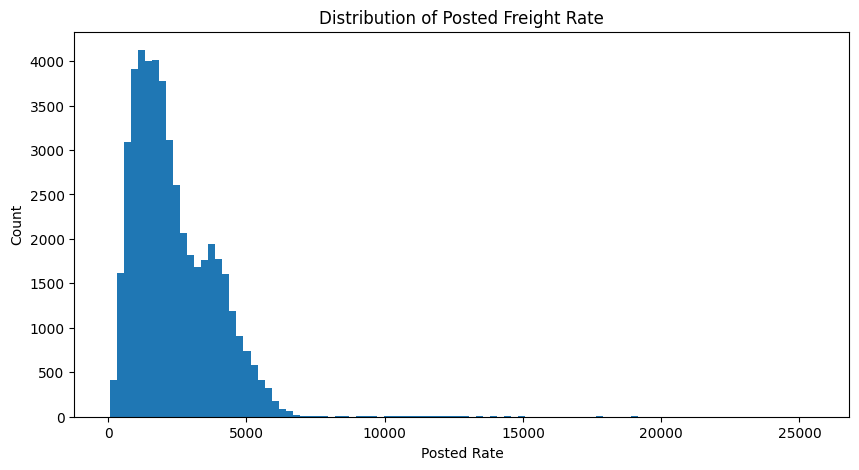

In [8]:
plt.figure(figsize=(10,5))
plt.hist(train["posted_rate"], bins=100)
plt.xlabel("Posted Rate")
plt.ylabel("Count")
plt.title("Distribution of Posted Freight Rate")
plt.show()

In [9]:
train["posted_rate"].describe()

,posted_rate
count,48000.000000
mean,2373.980682
std,1486.493245
min,57.220000
25%,1251.555000
50%,2030.760000
75%,3330.750000
max,25533.000000


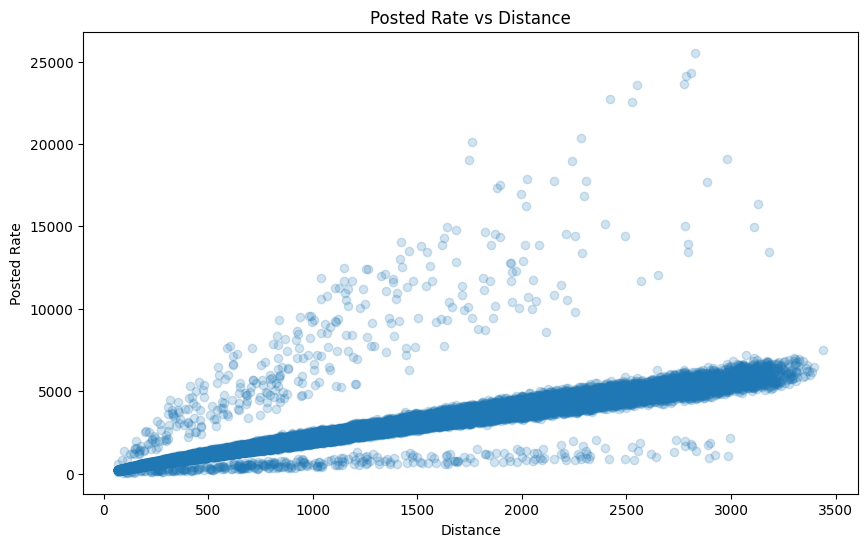

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    train["distance"],
    train["posted_rate"],
    alpha=0.2
)

plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.title("Posted Rate vs Distance")
plt.show()

In [11]:
train[["distance", "posted_rate"]].corr()

,distance,posted_rate
distance,1.000000,0.908519
posted_rate,0.908519,1.000000


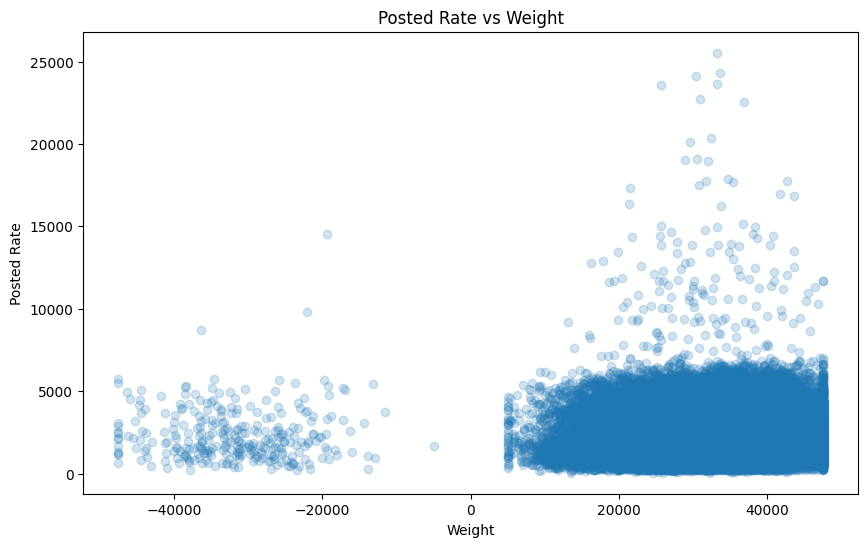

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    train["weight"],
    train["posted_rate"],
    alpha=0.2
)

plt.xlabel("Weight")
plt.ylabel("Posted Rate")
plt.title("Posted Rate vs Weight")
plt.show()

In [13]:
train["equipment"].value_counts()

,count
equipment,
Dry Van,27202
Reefer,12045
Flatbed,8753


In [14]:
train.groupby("equipment")["posted_rate"].agg(
    ["count", "mean", "median"]
).sort_values("count", ascending=False)

,count,mean,median
equipment,,,
Dry Van,27202,2271.548686,1953.035
Reefer,12045,2553.636939,2196.670
Flatbed,8753,2445.087223,2076.810


In [15]:
train["pickup"].nunique()
train["delivery"].nunique()

64

In [16]:
train.groupby("pickup")["posted_rate"].median().sort_values(ascending=False).head(10)

,posted_rate
pickup,
San Francisco,4301.810
Fresno,4160.280
Los Angeles,3996.610
Phoenix,3935.620
Reno,3836.925
Bakersfield,3804.880
Las Vegas,3633.060
Tucson,3535.995
Salt Lake City,3316.265


In [17]:
train.groupby("delivery")["posted_rate"].median().sort_values(ascending=False).head(10)

,posted_rate
delivery,
San Francisco,4356.600
Fresno,4140.170
Los Angeles,4046.090
Phoenix,3921.980
Reno,3783.880
Bakersfield,3742.535
Las Vegas,3707.765
Tucson,3591.790
Salt Lake City,3316.060


In [18]:
train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])

In [19]:
print(train["date"].min())
print(train["date"].max())

print(validation["date"].min())
print(validation["date"].max())

2025-01-01 00:00:00
2025-10-31 00:00:00
2025-11-01 00:00:00
2025-12-31 00:00:00


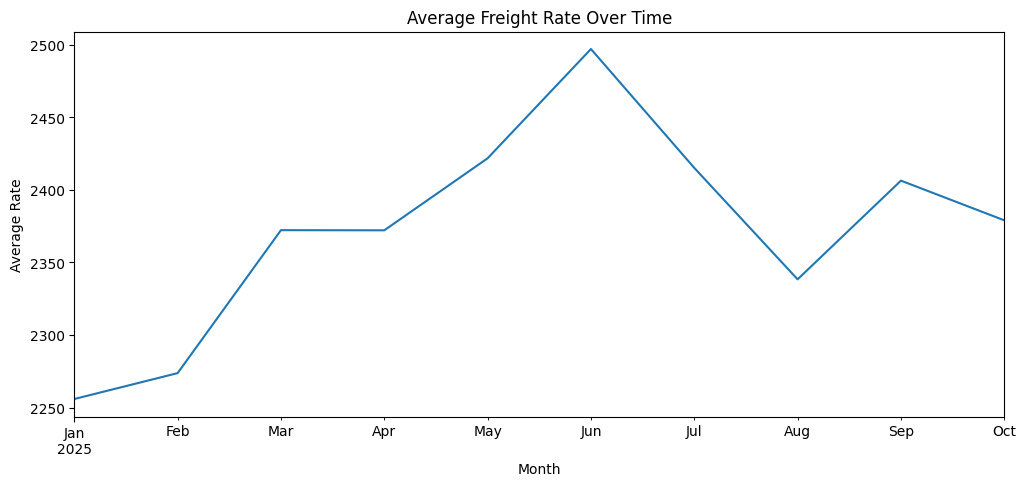

In [20]:
monthly = train.groupby(
    train["date"].dt.to_period("M")
)["posted_rate"].mean()

monthly.plot(figsize=(12,5))

plt.title("Average Freight Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rate")

plt.show()

In [21]:
cutoff = pd.Timestamp("2025-10-01")

train_dev = train[
    train["date"] < cutoff
].copy()

valid_dev = train[
    train["date"] >= cutoff
].copy()

In [22]:
print(train_dev.shape)
print(valid_dev.shape)

(43147, 14)
(4853, 14)


In [23]:
baseline_value = train_dev["posted_rate"].median()

baseline_pred = np.full(
    len(valid_dev),
    baseline_value
)

In [24]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    valid_dev["posted_rate"],
    baseline_pred
)

print(baseline_mae)

1146.7937069853701


In [25]:
import pandas as pd
import numpy as np

def create_features(df):
    df = df.copy()


    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["dayofyear"] = df["date"].dt.dayofyear
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)


    df["sin_doy"] = np.sin(
        2 * np.pi * df["dayofyear"] / 365
    )

    df["cos_doy"] = np.cos(
        2 * np.pi * df["dayofyear"] / 365
    )

    df["sin_dow"] = np.sin(
        2 * np.pi * df["dayofweek"] / 7
    )

    df["cos_dow"] = np.cos(
        2 * np.pi * df["dayofweek"] / 7
    )

    if "distance" in df.columns:
        df["distance_log"] = np.log1p(
            df["distance"].clip(lower=0)
        )

        df["distance_sq"] = df["distance"] ** 2

    if "weight" in df.columns:
        df["weight_log"] = np.log1p(
            df["weight"].clip(lower=0)
        )

    if "weight" in df.columns and "distance" in df.columns:
        df["weight_distance_ratio"] = (
            df["weight"] / (df["distance"] + 1)
        )


    if "pickup" in df.columns and "delivery" in df.columns:
        df["route"] = (
            df["pickup"].astype(str)
            + "_"
            + df["delivery"].astype(str)
        )

    return df

In [26]:
train_features = create_features(train)
validation_features = create_features(validation)
december_features = create_features(december)

print("Training shape:", train_features.shape)
print("Validation shape:", validation_features.shape)
print("December shape:", december_features.shape)

Training shape: (48000, 29)
Validation shape: (12000, 28)
December shape: (31, 22)


In [27]:
target = "posted_rate"

features = [
    col for col in train_features.columns
    if col != target
]

if "load_id" in features:
    features.remove("load_id")

print("Number of features:", len(features))
print(features)

Number of features: 27
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'sin_doy', 'cos_doy', 'sin_dow', 'cos_dow', 'distance_log', 'distance_sq', 'weight_log', 'weight_distance_ratio', 'route']


In [28]:
X = train_features[features]
y = train_features[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48000, 27)
y shape: (48000,)


In [29]:
categorical_features = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

# Keep only columns that actually exist
categorical_features = [
    col for col in categorical_features
    if col in X.columns
]

print("Categorical features:")
print(categorical_features)

Categorical features:
['pickup', 'delivery', 'equipment', 'route']


In [30]:
cat_indices = [
    X.columns.get_loc(col)
    for col in categorical_features
]

print("Categorical column indices:", cat_indices)

Categorical column indices: [0, 1, 7, 26]


In [31]:
cutoff_date = pd.Timestamp("2025-10-01")

train_mask = train_features["date"] < cutoff_date
valid_mask = train_features["date"] >= cutoff_date

X_train = train_features.loc[
    train_mask, features
]

y_train = train_features.loc[
    train_mask, target
]

X_valid = train_features.loc[
    valid_mask, features
]

y_valid = train_features.loc[
    valid_mask, target
]

In [32]:
print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))

print("\nTraining period:")
print(train_features.loc[train_mask, "date"].min())
print(train_features.loc[train_mask, "date"].max())

print("\nValidation period:")
print(train_features.loc[valid_mask, "date"].min())
print(train_features.loc[valid_mask, "date"].max())

Training rows: 43147
Validation rows: 4853

Training period:
2025-01-01 00:00:00
2025-09-30 00:00:00

Validation period:
2025-10-01 00:00:00
2025-10-31 00:00:00


Train

In [33]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [34]:
from catboost import CatBoostRegressor

In [35]:
model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [36]:
y_train_log = np.log1p(y_train)

model.fit(
    X_train,
    y_train_log,
    cat_features=cat_indices
)

0:	learn: 0.6347122	total: 120ms	remaining: 1m
100:	learn: 0.1517402	total: 10.3s	remaining: 40.6s
200:	learn: 0.1502654	total: 15.5s	remaining: 23.1s
300:	learn: 0.1491011	total: 18.6s	remaining: 12.3s
400:	learn: 0.1484205	total: 21.7s	remaining: 5.36s
499:	learn: 0.1476079	total: 25.3s	remaining: 0us


CatBoostRegressor(depth=8, iterations=500, l2_leaf_reg=5, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

Prediction

In [37]:
valid_log_pred = model.predict(X_valid)

# Convert log prediction back to original rate
valid_pred = np.expm1(valid_log_pred)

# Make sure predictions are positive
valid_pred = np.maximum(valid_pred, 0.01)

Calculate metrics

In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_valid,
    valid_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        valid_pred
    )
)

r2 = r2_score(
    y_valid,
    valid_pred
)

print("Validation Results")
print("------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Validation Results
------------------
MAE : 108.67902838994534
RMSE: 646.4959094647045
R²  : 0.8211172123325677


Calculate MAPE

In [39]:
def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )

mape = calculate_mape(y_valid, valid_pred)

print("MAPE:", mape, "%")

MAPE: 5.189847940757298 %


Actual vs predicted plot

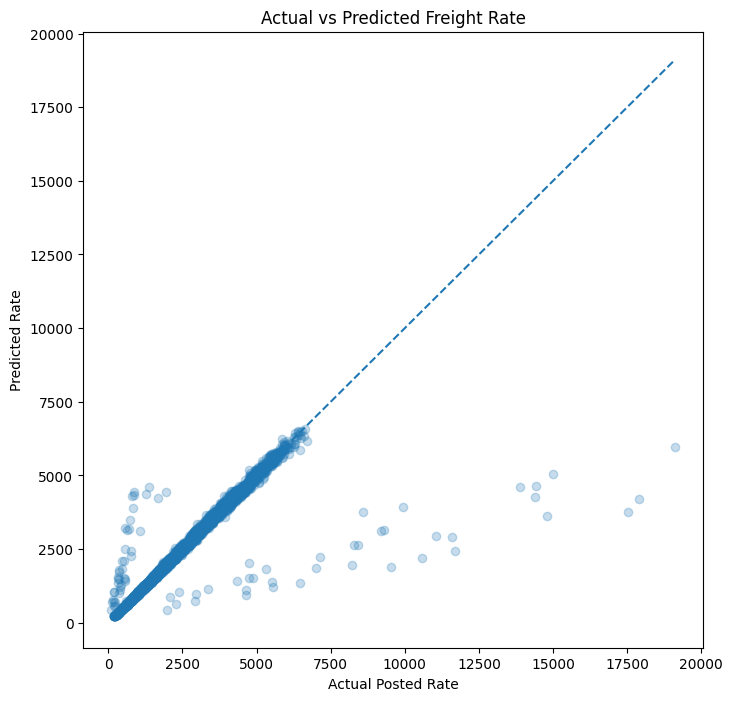

In [40]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_valid,
    valid_pred,
    alpha=0.25
)

# Perfect prediction line
min_value = min(y_valid.min(), valid_pred.min())
max_value = max(y_valid.max(), valid_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Posted Rate")
plt.ylabel("Predicted Rate")
plt.title("Actual vs Predicted Freight Rate")

plt.show()

Feature importance

In [41]:
importance = model.get_feature_importance()

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": importance
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
6,distance,32.051101
22,distance_log,28.931667
23,distance_sq,28.094479
7,equipment,3.078535
25,weight_distance_ratio,2.275406
24,weight_log,0.753452
10,market_index,0.543913
8,weight,0.502540
11,quote_signal,0.496562
2,pickup_lat,0.409828


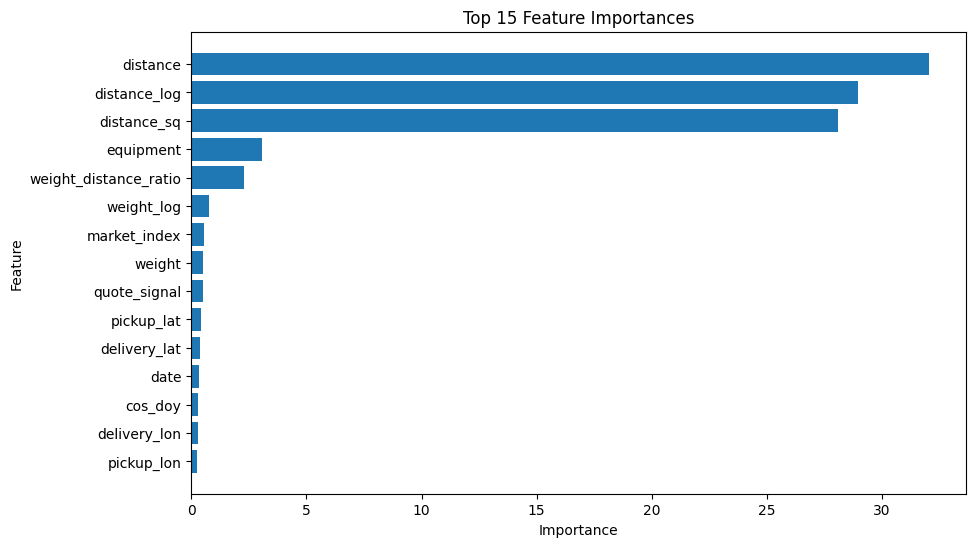

In [42]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.show()

Train the final model

In [43]:
final_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [44]:
X_full = train_features[features]
y_full = train_features[target]

y_full_log = np.log1p(y_full)

final_model.fit(
    X_full,
    y_full_log,
    cat_features=cat_indices
)

0:	learn: 0.6365141	total: 117ms	remaining: 58.4s
100:	learn: 0.1537691	total: 6.37s	remaining: 25.1s
200:	learn: 0.1511266	total: 12.4s	remaining: 18.4s
300:	learn: 0.1497187	total: 18.1s	remaining: 12s
400:	learn: 0.1487114	total: 23.7s	remaining: 5.86s
499:	learn: 0.1477356	total: 29.5s	remaining: 0us


CatBoostRegressor(depth=8, iterations=500, l2_leaf_reg=5, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

Predict the 12,000 validation loads

In [45]:
X_final_validation = validation_features[features]

In [46]:
validation_log_pred = final_model.predict(
    X_final_validation
)

In [47]:
validation_pred = np.expm1(
    validation_log_pred
)

validation_pred = np.maximum(
    validation_pred,
    0.01
)

In [48]:
print("Number of predictions:", len(validation_pred))
print("Minimum prediction:", validation_pred.min())
print("Maximum prediction:", validation_pred.max())

Number of predictions: 12000
Minimum prediction: 205.57446152372086
Maximum prediction: 6786.450022847932


Create validation_predictions.csv

In [49]:
final_predictions = template.copy()

final_predictions["predicted_rate"] = validation_pred

In [50]:
print(final_predictions.head())
print(final_predictions.shape)
print(final_predictions.columns.tolist())

     load_id  predicted_rate
0  TE-000001      840.516344
1  TE-000002     5065.196672
2  TE-000003     5189.069277
3  TE-000004     3974.331438
4  TE-000005     1816.876923
(12000, 2)
['load_id', 'predicted_rate']


In [51]:
print("Rows:", len(final_predictions))

print(
    "Unique load IDs:",
    final_predictions["load_id"].nunique()
)

print(
    "Missing predictions:",
    final_predictions["predicted_rate"].isna().sum()
)

print(
    "Non-positive predictions:",
    (final_predictions["predicted_rate"] <= 0).sum()
)

Rows: 12000
Unique load IDs: 12000
Missing predictions: 0
Non-positive predictions: 0


In [52]:
final_predictions.to_csv(
    "validation_predictions.csv",
    index=False
)

print("Saved validation_predictions.csv")

Saved validation_predictions.csv


December predictions

In [53]:
december.head()
print(december.columns.tolist())

['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [54]:
missing_features = [
    col for col in features
    if col not in december_features.columns
]

print("Features missing from December:")
print(missing_features)

Features missing from December:
['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'market_index', 'quote_signal']


In [55]:
pickup_coordinates = (
    train.groupby("pickup")[
        ["pickup_lat", "pickup_lon"]
    ]
    .median()
)

delivery_coordinates = (
    train.groupby("delivery")[
        ["delivery_lat", "delivery_lon"]
    ]
    .median()
)

In [56]:
print(
    pickup_coordinates.loc["Lexington"]
)

pickup_lat    36.99152
pickup_lon   -84.99876
Name: Lexington, dtype: float64


In [57]:
print(
    delivery_coordinates.loc["Fort Wayne"]
)

delivery_lat    41.31561
delivery_lon   -85.36206
Name: Fort Wayne, dtype: float64


In [58]:
december_model = december.copy()

december_model["pickup_lat"] = december_model["pickup"].map(
    pickup_coordinates["pickup_lat"]
)

december_model["pickup_lon"] = december_model["pickup"].map(
    pickup_coordinates["pickup_lon"]
)

december_model["delivery_lat"] = december_model["delivery"].map(
    delivery_coordinates["delivery_lat"]
)

december_model["delivery_lon"] = december_model["delivery"].map(
    delivery_coordinates["delivery_lon"]
)

In [59]:
december_model[
    [
        "pickup",
        "delivery",
        "pickup_lat",
        "pickup_lon",
        "delivery_lat",
        "delivery_lon"
    ]
].head()

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon
0,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206
1,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206
2,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206
3,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206
4,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206


In [60]:
recent_data = train[
    train["date"] >= "2025-10-01"
].copy()

In [61]:
market_index_median = recent_data[
    "market_index"
].median()

quote_signal_median = recent_data[
    "quote_signal"
].median()

print("Market index:", market_index_median)
print("Quote signal:", quote_signal_median)

Market index: 0.95818
Quote signal: 1.98584


In [62]:
december_model["market_index"] = market_index_median
december_model["quote_signal"] = quote_signal_median

In [63]:
december_model = create_features(
    december_model
)

In [64]:
print(december_model.shape)
print(december_model.columns.tolist())

(31, 28)
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'market_index', 'quote_signal', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'sin_doy', 'cos_doy', 'sin_dow', 'cos_dow', 'distance_log', 'distance_sq', 'weight_log', 'weight_distance_ratio', 'route']


In [65]:
missing = [
    col for col in features
    if col not in december_model.columns
]

print("Still missing:", missing)

Still missing: []


Predict December

In [66]:
X_december = december_model[features]

In [67]:
december_log_pred = final_model.predict(
    X_december
)

In [68]:
december_pred = np.expm1(
    december_log_pred
)

december_pred = np.maximum(
    december_pred,
    0.01
)

In [69]:
print(december_pred)

[804.95601187 813.53646879 823.01916504 816.35195247 813.54037582
 815.48183546 809.86733166 804.65433352 813.35904782 823.26098457
 816.25050126 813.34794749 816.04802982 811.1875546  808.88087513
 816.93825796 827.11308495 820.23189807 817.03897599 817.42822164
 811.95701142 809.15415187 816.92219788 826.72736534 820.2262731
 817.86640919 820.75008737 815.59799066 804.79425991 805.03017255
 813.92828144]


In [70]:
december_output = december.copy()

december_output["predicted_rate"] = december_pred

In [71]:
print(december_output.head())
print(december_output.shape)
print(december_output.columns.tolist())

      pickup    delivery  distance equipment  weight        date  \
0  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   

   predicted_rate  
0      804.956012  
1      813.536469  
2      823.019165  
3      816.351952  
4      813.540376  
(31, 7)
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [72]:
print("Rows:", len(december_output))

print(
    "Unique dates:",
    december_output["date"].nunique()
)

print(
    "Missing predictions:",
    december_output["predicted_rate"].isna().sum()
)

print(
    "Non-positive predictions:",
    (
        december_output["predicted_rate"] <= 0
    ).sum()
)

Rows: 31
Unique dates: 31
Missing predictions: 0
Non-positive predictions: 0


In [73]:
december_output.to_csv(
    "december_chart_inputs_completed.csv",
    index=False
)

print(
    "Saved december_chart_inputs_completed.csv"
)

Saved december_chart_inputs_completed.csv


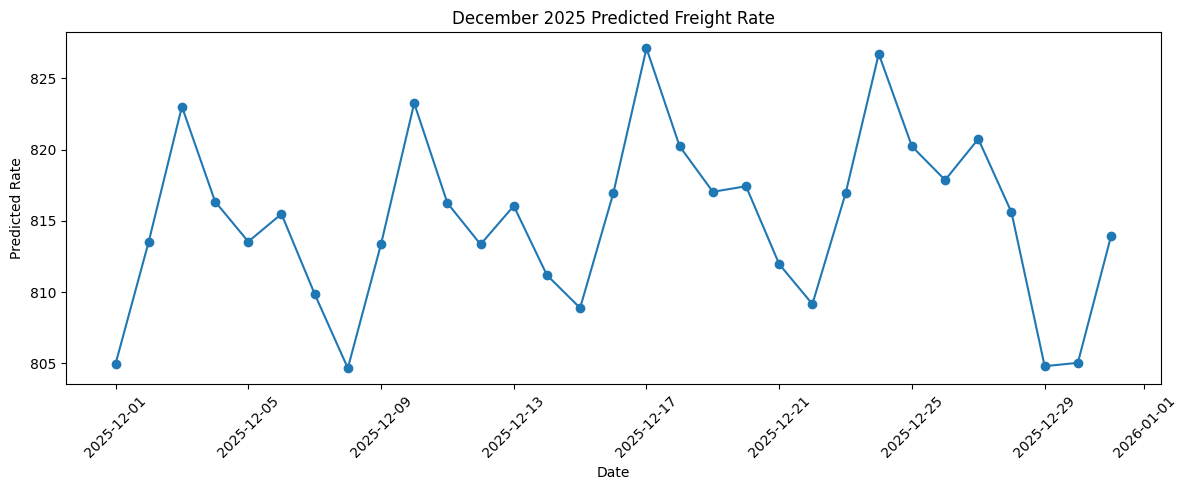

In [74]:
december_output["date"] = pd.to_datetime(
    december_output["date"]
)

december_output = december_output.sort_values(
    "date"
)

plt.figure(figsize=(12, 5))

plt.plot(
    december_output["date"],
    december_output["predicted_rate"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Predicted Rate")
plt.title(
    "December 2025 Predicted Freight Rate"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [78]:
!python //content/score.py \
    --predictions validation_predictions.csv \
    --december-predictions december_chart_inputs_completed.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


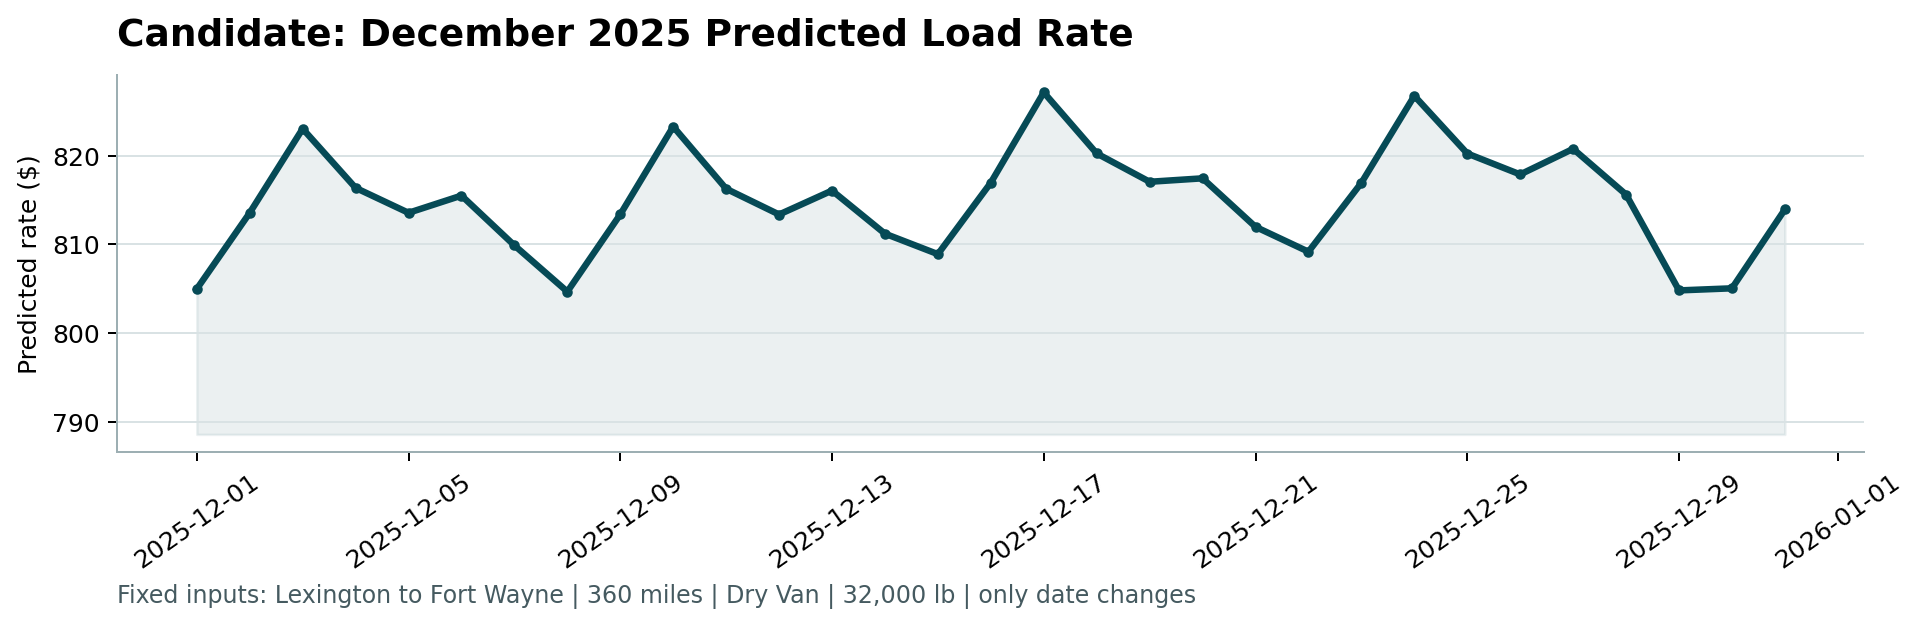

In [79]:
from IPython.display import Image, display

display(
    Image(
        filename="scorer_results/candidate_december.png"
    )
)

Download prediction files

In [80]:
from google.colab import files

files.download("validation_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
files.download("december_chart_inputs_completed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [82]:
files.download("scorer_results/candidate_december.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_pred = np.full(
    len(y_valid),
    y_train.median()
)

baseline_mae = mean_absolute_error(
    y_valid,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_valid,
    baseline_pred
)

print("Baseline Results")
print("----------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

Baseline Results
----------------
MAE : 1146.7937069853701
RMSE: 1567.9704854490194
R²  : -0.05223503666552376


Linear Regression

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

In [85]:
numeric_features = [
    col for col in features
    if col not in categorical_features
]

categorical_features_lr = [
    col for col in categorical_features
    if col in features
]

In [86]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features_lr
        )
    ]
)

In [87]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10.0))
])

In [90]:
print(X_train.dtypes)
print(y_train.dtypes)


pickup                           object
delivery                         object
pickup_lat                      float64
pickup_lon                      float64
delivery_lat                    float64
delivery_lon                    float64
distance                        float64
equipment                        object
weight                          float64
date                     datetime64[ns]
market_index                    float64
quote_signal                    float64
year                              int32
month                             int32
day                               int32
dayofweek                         int32
dayofyear                         int32
weekofyear                        int64
sin_doy                         float64
cos_doy                         float64
sin_dow                         float64
cos_dow                         float64
distance_log                    float64
distance_sq                     float64
weight_log                      float64


In [91]:
ridge_model.fit(
    X_train,
    y_train
)

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int32DType'>, <class 'numpy.dtypes.Int32DType'>, <class 'numpy.dtypes.Int32DType'>, <class 'numpy.dtypes.Int32DType'>, <class 'numpy.dtypes.Int32DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <c

In [92]:
print("Categorical columns:")
print(categorical_features_lr)

print("\nNumeric columns:")
print(numeric_features)

Categorical columns:
['pickup', 'delivery', 'equipment', 'route']

Numeric columns:
['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'date', 'market_index', 'quote_signal', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'sin_doy', 'cos_doy', 'sin_dow', 'cos_dow', 'distance_log', 'distance_sq', 'weight_log', 'weight_distance_ratio']


In [93]:
for col in X_train.columns:
    print(col, X_train[col].dtype)

pickup object
delivery object
pickup_lat float64
pickup_lon float64
delivery_lat float64
delivery_lon float64
distance float64
equipment object
weight float64
date datetime64[ns]
market_index float64
quote_signal float64
year int32
month int32
day int32
dayofweek int32
dayofyear int32
weekofyear int64
sin_doy float64
cos_doy float64
sin_dow float64
cos_dow float64
distance_log float64
distance_sq float64
weight_log float64
weight_distance_ratio float64
route object


In [94]:
X_train.select_dtypes(
    include=["datetime"]
).columns

Index(['date'], dtype='object')

In [95]:
X_train_ridge = X_train.drop(columns=["date"], errors="ignore")
X_valid_ridge = X_valid.drop(columns=["date"], errors="ignore")

In [96]:
categorical_features_lr = [
    col for col in categorical_features
    if col in X_train_ridge.columns
]

numeric_features_lr = [
    col for col in X_train_ridge.columns
    if col not in categorical_features_lr
]

In [97]:
preprocessor_ridge = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features_lr
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(handle_unknown="ignore")
                )
            ]),
            categorical_features_lr
        )
    ]
)

In [98]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor_ridge),
    ("model", Ridge(alpha=10.0))
])

In [99]:
ridge_model.fit(
    X_train_ridge,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['pickup_lat', 'pickup_lon',
                                                   'delivery_lat',
                                                   'delivery_lon', 'distance',
                                                   'weight', 'market_index',
                                                   'quote_signal', 'year',
                                                   'month', 'day', 'dayofweek',
                                                   'dayofyear', 'weekofyear',
                                                   'sin_doy', 'cos_doy',
                                                   'sin_dow', 'cos_dow',
                                                   'distance_log',
                                                   'distance_sq', 'weight_log',
                                                   'weight_distance_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pickup', 'delivery',
                                                   'equipment', 'route'])])),
                ('model', Ridge(alpha=10.0))])

In [100]:
ridge_pred = ridge_model.predict(
    X_valid_ridge
)

ridge_pred = np.maximum(
    ridge_pred,
    0.01
)

In [101]:
ridge_mae = mean_absolute_error(
    y_valid,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        ridge_pred
    )
)

ridge_r2 = r2_score(
    y_valid,
    ridge_pred
)

print("Ridge Regression")
print("----------------")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression
----------------
MAE : 410.81644925987104
RMSE: 782.8278320765437
R²  : 0.7377173836675075


Random Forest

In [102]:
from sklearn.ensemble import RandomForestRegressor

In [103]:
rf_model = Pipeline([
    (
        "preprocessor",
        preprocessor_ridge
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [104]:
rf_model.fit(
    X_train_ridge,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['pickup_lat', 'pickup_lon',
                                                   'delivery_lat',
                                                   'delivery_lon', 'distance',
                                                   'weight', 'market_index',
                                                   'quote_signal', 'year',
                                                   'month', 'day', 'dayofweek',
                                                   'dayofyear', 'weekofyear',
                                                   'sin_doy', 'cos_doy',
                                                   'sin_dow', 'cos_dow',
                                                   'distance_log',
                                                   'distance_sq', 'weight_log',
                                                   'weight_distance_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pickup', 'delivery',
                                                   'equipment', 'route'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=2,
                                       n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [105]:
rf_pred = rf_model.predict(
    X_valid_ridge
)

rf_pred = np.maximum(
    rf_pred,
    0.01
)

In [106]:
rf_mae = mean_absolute_error(
    y_valid,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_valid,
    rf_pred
)

print("Random Forest")
print("-------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
-------------
MAE : 188.50733155639938
RMSE: 704.2327574722275
R²  : 0.7877393760849452


Comparision

In [107]:
comparison = pd.DataFrame({
    "Model": [
        "Median Baseline",
        "Ridge Regression",
        "Random Forest",
        "CatBoost Log Target"
    ],
    "MAE": [
        baseline_mae,
        ridge_mae,
        rf_mae,
        mae
    ],
    "RMSE": [
        baseline_rmse,
        ridge_rmse,
        rf_rmse,
        rmse
    ],
    "R2": [
        baseline_r2,
        ridge_r2,
        rf_r2,
        r2
    ]
})

comparison.sort_values("MAE")

,Model,MAE,RMSE,R2
3,CatBoost Log Target,108.679028,646.495909,0.821117
2,Random Forest,188.507332,704.232757,0.787739
1,Ridge Regression,410.816449,782.827832,0.737717
0,Median Baseline,1146.793707,1567.970485,-0.052235


In [ ]:
CatBoost Raw Target

In [108]:
from catboost import CatBoostRegressor

raw_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [109]:
raw_model.fit(
    X_train,
    y_train,
    cat_features=cat_indices
)

0:	learn: 1423.0207441	total: 93.5ms	remaining: 46.6s
100:	learn: 579.1427116	total: 6.07s	remaining: 24s
200:	learn: 569.7366368	total: 9.92s	remaining: 14.8s
300:	learn: 563.2104785	total: 13.4s	remaining: 8.87s
400:	learn: 556.6882807	total: 18.3s	remaining: 4.51s
499:	learn: 551.8691501	total: 22.6s	remaining: 0us


CatBoostRegressor(depth=8, iterations=500, l2_leaf_reg=5, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [110]:
raw_pred = raw_model.predict(X_valid)

raw_pred = np.maximum(
    raw_pred,
    0.01
)

In [111]:
raw_mae = mean_absolute_error(
    y_valid,
    raw_pred
)

raw_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        raw_pred
    )
)

raw_r2 = r2_score(
    y_valid,
    raw_pred
)

print("CatBoost - Raw Target")
print("---------------------")
print("MAE :", raw_mae)
print("RMSE:", raw_rmse)
print("R²  :", raw_r2)

CatBoost - Raw Target
---------------------
MAE : 139.99597114509905
RMSE: 649.5654404162605
R²  : 0.8194145263210304


compare the two CatBoost versions

In [112]:
catboost_comparison = pd.DataFrame({
    "Model": [
        "CatBoost Raw Target",
        "CatBoost Log Target"
    ],
    "MAE": [
        raw_mae,
        mae
    ],
    "RMSE": [
        raw_rmse,
        rmse
    ],
    "R2": [
        raw_r2,
        r2
    ]
})

catboost_comparison.sort_values("MAE")

,Model,MAE,RMSE,R2
1,CatBoost Log Target,108.679028,646.495909,0.821117
0,CatBoost Raw Target,139.995971,649.565440,0.819415


In [113]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [114]:
def evaluate_catboost(
    iterations,
    depth,
    learning_rate,
    l2_leaf_reg
):

    model = CatBoostRegressor(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        np.log1p(y_train),
        cat_features=cat_indices
    )

    prediction_log = model.predict(X_valid)

    prediction = np.expm1(prediction_log)

    prediction = np.maximum(
        prediction,
        0.01
    )

    mae_value = mean_absolute_error(
        y_valid,
        prediction
    )

    rmse_value = np.sqrt(
        mean_squared_error(
            y_valid,
            prediction
        )
    )

    r2_value = r2_score(
        y_valid,
        prediction
    )

    return {
        "iterations": iterations,
        "depth": depth,
        "learning_rate": learning_rate,
        "l2_leaf_reg": l2_leaf_reg,
        "MAE": mae_value,
        "RMSE": rmse_value,
        "R2": r2_value
    }

In [115]:
tuning_results = []

configs = [
    {
        "iterations": 300,
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 5
    },

    {
        "iterations": 500,
        "depth": 8,
        "learning_rate": 0.05,
        "l2_leaf_reg": 5
    },

    {
        "iterations": 700,
        "depth": 8,
        "learning_rate": 0.03,
        "l2_leaf_reg": 8
    },

    {
        "iterations": 600,
        "depth": 10,
        "learning_rate": 0.04,
        "l2_leaf_reg": 8
    }
]

In [116]:
for config in configs:

    print("Testing:", config)

    result = evaluate_catboost(
        iterations=config["iterations"],
        depth=config["depth"],
        learning_rate=config["learning_rate"],
        l2_leaf_reg=config["l2_leaf_reg"]
    )

    tuning_results.append(result)

Testing: {'iterations': 300, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 5}
Testing: {'iterations': 500, 'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 5}
Testing: {'iterations': 700, 'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 8}
Testing: {'iterations': 600, 'depth': 10, 'learning_rate': 0.04, 'l2_leaf_reg': 8}


In [117]:
tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df.sort_values(
    "MAE"
)

,iterations,depth,learning_rate,l2_leaf_reg,MAE,RMSE,R2
0,300,6,0.05,5,107.702811,648.197733,0.820174
3,600,10,0.04,8,108.351002,645.978727,0.821403
2,700,8,0.03,8,108.534915,646.327348,0.821210
1,500,8,0.05,5,108.679028,646.495909,0.821117


Best configuration

In [119]:
best_result = tuning_results_df.sort_values(
    "MAE"
).iloc[0]

print(best_result)

iterations       300.000000
depth              6.000000
learning_rate      0.050000
l2_leaf_reg        5.000000
MAE              107.702811
RMSE             648.197733
R2                 0.820174
Name: 0, dtype: float64


In [120]:
best_iterations = int(
    best_result["iterations"]
)

best_depth = int(
    best_result["depth"]
)

best_learning_rate = float(
    best_result["learning_rate"]
)

best_l2_leaf_reg = float(
    best_result["l2_leaf_reg"]
)

print("Best configuration:")
print("Iterations:", best_iterations)
print("Depth:", best_depth)
print("Learning rate:", best_learning_rate)
print("L2:", best_l2_leaf_reg)

Best configuration:
Iterations: 300
Depth: 6
Learning rate: 0.05
L2: 5.0


In [121]:
tuning_results_df.sort_values("MAE")

,iterations,depth,learning_rate,l2_leaf_reg,MAE,RMSE,R2
0,300,6,0.05,5,107.702811,648.197733,0.820174
3,600,10,0.04,8,108.351002,645.978727,0.821403
2,700,8,0.03,8,108.534915,646.327348,0.821210
1,500,8,0.05,5,108.679028,646.495909,0.821117


In [122]:
print(train.columns.tolist())

['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']


In [123]:
print("Training missing values:")
print(train[[
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "date",
    "market_index",
    "quote_signal"
]].isnull().sum())

Training missing values:
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
dtype: int64


In [124]:
print("\nValidation missing values:")
print(validation[[
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "date",
    "market_index",
    "quote_signal"
]].isnull().sum())


Validation missing values:
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64


In [125]:
print("Training weight missing:")
print(train.loc[train["weight"].isna(), ["weight", "distance", "posted_rate"]].head(10))

print("\nTraining market_index missing:")
print(train.loc[train["market_index"].isna(), ["market_index", "date", "posted_rate"]].head(10))

Training weight missing:
      weight  distance  posted_rate
323      NaN    2848.8      5430.07
648      NaN     467.0      1178.03
694      NaN     432.6      1022.13
732      NaN    2497.6      4991.60
911      NaN     887.8      1643.25
942      NaN     833.9      1602.03
963      NaN     640.8      1466.95
1009     NaN     550.2      1161.37
1021     NaN     678.8      1318.04
1058     NaN     714.8      1431.30

Training market_index missing:
      market_index       date  posted_rate
116            NaN 2025-01-01      1271.10
226            NaN 2025-01-02      2743.13
311            NaN 2025-01-02      5568.57
511            NaN 2025-01-04      2786.63
531            NaN 2025-01-04      3295.80
629            NaN 2025-01-05      1256.20
644            NaN 2025-01-05      2171.37
905            NaN 2025-01-06       231.54
1012           NaN 2025-01-07      2236.76
1274           NaN 2025-01-08      1186.43


In [126]:
print("Weight median:", train["weight"].median())
print("Market index median:", train["market_index"].median())

Weight median: 31436.5
Market index median: 1.0558


In [127]:
weight_median = train["weight"].median()

train["weight"] = train["weight"].fillna(weight_median)

validation["weight"] = validation["weight"].fillna(weight_median)

december["weight"] = december["weight"].fillna(weight_median)

In [128]:
weight_median = train["weight"].median()

In [129]:
market_index_median = train["market_index"].median()

print(
    "Market index median:",
    market_index_median
)

Market index median: 1.0558


In [131]:
train["market_index"] = train[
    "market_index"
].fillna(market_index_median)

validation["market_index"] = validation[
    "market_index"
].fillna(market_index_median)

december["market_index"] = december[
    "market_index"
].fillna(market_index_median)

KeyError: 'market_index'

In [132]:
print(train[["pickup", "delivery", "equipment"]].isna().sum())

pickup       0
delivery     0
equipment    0
dtype: int64


In [133]:
print(validation[["pickup", "delivery", "equipment"]].isna().sum())

pickup       0
delivery     0
equipment    0
dtype: int64


In [134]:
print(train[["pickup", "delivery", "equipment"]].isna().sum())
print(validation[["pickup", "delivery", "equipment"]].isna().sum())

pickup       0
delivery     0
equipment    0
dtype: int64
pickup       0
delivery     0
equipment    0
dtype: int64


Final Model

In [135]:
from catboost import CatBoostRegressor
import numpy as np

final_model = CatBoostRegressor(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [136]:
X_full = train_features[features]
y_full = train_features["posted_rate"]

y_full_log = np.log1p(y_full)

print("Training rows:", len(X_full))
print("Training features:", X_full.shape[1])

Training rows: 48000
Training features: 27


In [137]:
final_model.fit(
    X_full,
    y_full_log,
    cat_features=cat_indices
)

0:	learn: 0.6374268	total: 58ms	remaining: 17.3s
100:	learn: 0.1548323	total: 3.87s	remaining: 7.63s
200:	learn: 0.1527066	total: 7.5s	remaining: 3.69s
299:	learn: 0.1517193	total: 11.5s	remaining: 0us


CatBoostRegressor(depth=6, iterations=300, l2_leaf_reg=5, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [138]:
X_final_validation = validation_features[features]

print(
    "Validation rows:",
    len(X_final_validation)
)

Validation rows: 12000


In [139]:
validation_log_pred = final_model.predict(
    X_final_validation
)

validation_pred = np.expm1(
    validation_log_pred
)

validation_pred = np.maximum(
    validation_pred,
    0.01
)

In [140]:
print("Predictions:", len(validation_pred))
print("Minimum:", validation_pred.min())
print("Maximum:", validation_pred.max())
print("Missing:", np.isnan(validation_pred).sum())

Predictions: 12000
Minimum: 208.39133471149628
Maximum: 6668.238380026631
Missing: 0


Create Final model CSV file

In [141]:
final_predictions = template.copy()

final_predictions["predicted_rate"] = validation_pred

In [142]:
print(final_predictions.head())
print(final_predictions.shape)
print(final_predictions.columns.tolist())

     load_id  predicted_rate
0  TE-000001      854.991313
1  TE-000002     5007.727738
2  TE-000003     5237.404680
3  TE-000004     4014.295138
4  TE-000005     1780.584629
(12000, 2)
['load_id', 'predicted_rate']


In [143]:
final_predictions.to_csv(
    "validation_predictions.csv",
    index=False
)

print("✅ validation_predictions.csv created")

✅ validation_predictions.csv created


In [144]:
assert len(final_predictions) == 12000
assert final_predictions["load_id"].nunique() == 12000
assert final_predictions["predicted_rate"].notna().all()
assert (final_predictions["predicted_rate"] > 0).all()

print("✅ All validation prediction checks passed!")

✅ All validation prediction checks passed!


In [145]:
print("Training rows:", len(X_full))
print("Validation rows:", len(X_final_validation))
print("Predictions:", len(validation_pred))
print("Minimum:", validation_pred.min())
print("Maximum:", validation_pred.max())
print("Missing:", np.isnan(validation_pred).sum())

Training rows: 48000
Validation rows: 12000
Predictions: 12000
Minimum: 208.39133471149628
Maximum: 6668.238380026631
Missing: 0


In [146]:
final_predictions.to_csv(
    "validation_predictions.csv",
    index=False
)

print("✅ Final validation_predictions.csv saved")

✅ Final validation_predictions.csv saved


December predictions

In [147]:
december_final = december.copy()

print(december_final.shape)
print(december_final.columns.tolist())

(31, 7)
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [148]:
december_model = december.copy()

december_model["date"] = pd.to_datetime(
    december_model["date"]
)

print(december_model.head())

      pickup    delivery  distance equipment  weight       date  \
0  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-05   

   predicted_rate  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  


In [149]:
pickup_coordinates = (
    train.groupby("pickup")[
        ["pickup_lat", "pickup_lon"]
    ]
    .median()
)

delivery_coordinates = (
    train.groupby("delivery")[
        ["delivery_lat", "delivery_lon"]
    ]
    .median()
)

In [150]:
december_model["pickup_lat"] = december_model[
    "pickup"
].map(
    pickup_coordinates["pickup_lat"]
)

december_model["pickup_lon"] = december_model[
    "pickup"
].map(
    pickup_coordinates["pickup_lon"]
)

december_model["delivery_lat"] = december_model[
    "delivery"
].map(
    delivery_coordinates["delivery_lat"]
)

december_model["delivery_lon"] = december_model[
    "delivery"
].map(
    delivery_coordinates["delivery_lon"]
)

In [151]:
print(
    december_model[
        [
            "pickup",
            "delivery",
            "pickup_lat",
            "pickup_lon",
            "delivery_lat",
            "delivery_lon"
        ]
    ]
)

       pickup    delivery  pickup_lat  pickup_lon  delivery_lat  delivery_lon
0   Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
1   Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
2   Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
3   Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
4   Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
5   Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
6   Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
7   Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
8   Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
9   Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
10  Lexington  Fort Wayne    36.99152   -84.99876      41.31561     -85.36206
11  Lexington  Fort Wayne    36.99152   -84.99876      41.31561 

In [152]:
recent_data = train[
    train["date"] >= "2025-10-01"
].copy()

In [153]:
market_index_recent_median = recent_data[
    "market_index"
].median()

quote_signal_recent_median = recent_data[
    "quote_signal"
].median()

print(
    "Recent market_index median:",
    market_index_recent_median
)

print(
    "Recent quote_signal median:",
    quote_signal_recent_median
)

Recent market_index median: 0.95911
Recent quote_signal median: 1.98584


In [154]:
december_model["market_index"] = (
    market_index_recent_median
)

december_model["quote_signal"] = (
    quote_signal_recent_median
)

In [155]:
december_model = create_features(
    december_model
)

In [156]:
missing_features = [
    col
    for col in features
    if col not in december_model.columns
]

print(
    "Missing model features:",
    missing_features
)

Missing model features: []


In [157]:
X_december = december_model[features]

print(
    "December model input shape:",
    X_december.shape
)

December model input shape: (31, 27)


In [158]:
december_log_pred = final_model.predict(
    X_december
)

In [159]:
december_pred = np.expm1(
    december_log_pred
)

december_pred = np.maximum(
    december_pred,
    0.01
)

In [160]:
print("Number of predictions:", len(december_pred))
print("Minimum:", december_pred.min())
print("Maximum:", december_pred.max())

Number of predictions: 31
Minimum: 825.7534917114538
Maximum: 838.9662114609323


In [161]:
december_output = december.copy()

december_output["predicted_rate"] = december_pred

In [162]:
print(
    december_output.columns.tolist()
)

['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [163]:
assert len(december_output) == 31

assert december_output["date"].nunique() == 31

assert december_output["predicted_rate"].notna().all()

assert (
    december_output["predicted_rate"] > 0
).all()

assert december_output["pickup"].eq(
    "Lexington"
).all()

assert december_output["delivery"].eq(
    "Fort Wayne"
).all()

assert np.isclose(
    december_output["distance"],
    360
).all()

assert december_output["equipment"].eq(
    "Dry Van"
).all()

assert np.isclose(
    december_output["weight"],
    32000
).all()

print("✅ All December checks passed!")

✅ All December checks passed!


In [164]:
december_output.to_csv(
    "december_chart_inputs_completed.csv",
    index=False
)

print(
    "✅ december_chart_inputs_completed.csv saved"
)

✅ december_chart_inputs_completed.csv saved


Running score.py

In [165]:
!python /content/score.py \
    --predictions validation_predictions.csv \
    --december-predictions december_chart_inputs_completed.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


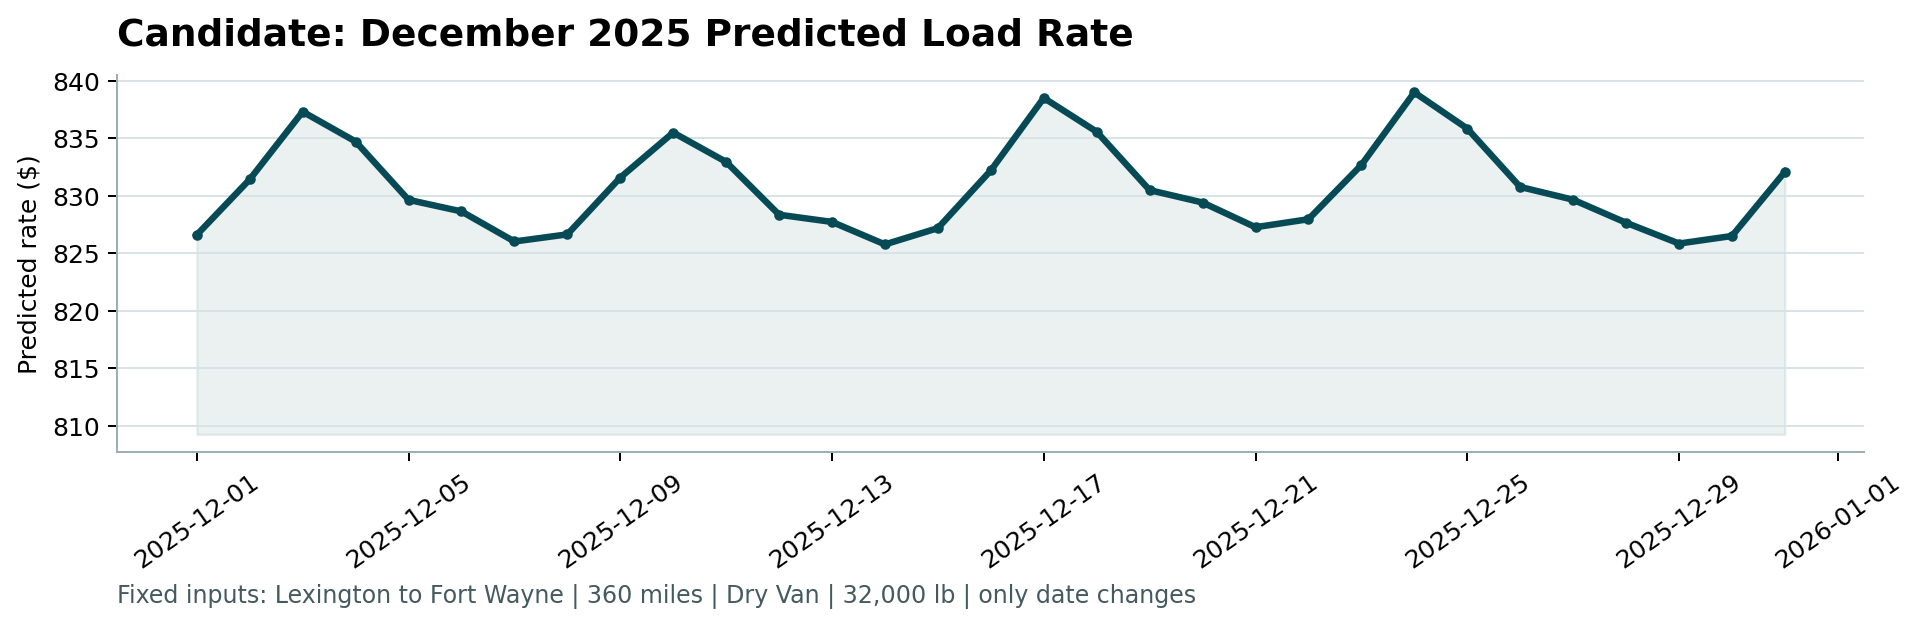

In [166]:
from IPython.display import Image, display

display(
    Image(
        filename="scorer_results/candidate_december.png"
    )
)

Files of the final model prediction

In [168]:
from google.colab import files

files.download("validation_predictions.csv")
files.download("december_chart_inputs_completed.csv")
files.download(
    "scorer_results/candidate_december.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>